In [1]:
!pip install dtreeviz

In [38]:
import graphviz.backend as be
from sklearn.datasets import load_iris
from IPython.display import Image,display_svg, SVG

In [3]:
from sklearn import tree
clas = tree.DecisionTreeClassifier(max_depth=2)
iris = load_iris()
X_train = iris.data

In [4]:
y_train = iris.target

In [5]:
clas.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2)

[Text(0.4, 0.8333333333333334, 'x[2] <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.043\nsamples = 46\nvalue = [0, 1, 45]')]

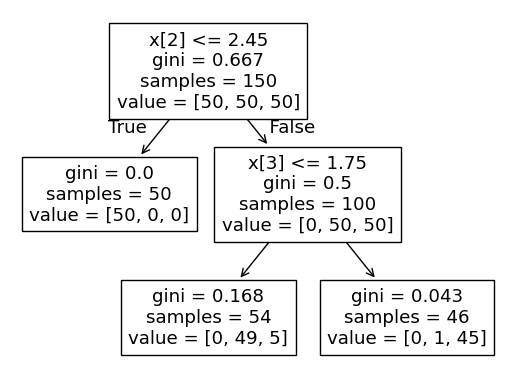

In [6]:
from sklearn.tree import plot_tree
plot_tree(clas)

## 1 . Classification



In [7]:
import dtreeviz
model_viz = dtreeviz.model(clas, X_train, y_train,
                           feature_names=iris.feature_names,
                           class_names=iris.target_names)
viz = model_viz.view()

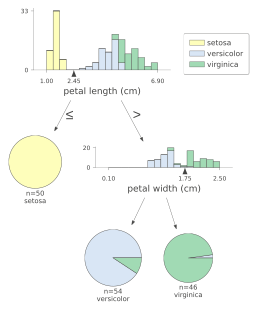

In [8]:
viz

## 2.Regression

Streaming output truncated to the last 5000 lines.


KeyboardInterrupt: 

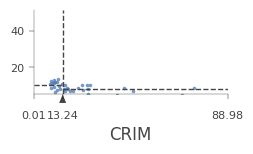

In [9]:
regr = tree.DecisionTreeRegressor()

import pandas as pd
import numpy as np
import dtreeviz # Added import for self-contained cell

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# Correctly combine features and extract target as done previously
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Assign the correctly processed data and target
X_train = data
y_train = target
regr.fit(X_train,y_train)

# Define feature names for the Boston dataset (13 features)
boston_feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
    'PTRATIO', 'B', 'LSTAT'
]
boston_target_name = "price" # Using the user's intended target name

# Using the dtreeviz.model().view() interface for regression
model_viz_regr = dtreeviz.model(regr, X_train, y_train,
                                feature_names=boston_feature_names,
                                target_name=boston_target_name)
vir = model_viz_regr.view()

In [ ]:
vir

### Horizantal Decision Tree

In [13]:
import dtreeviz
X_train = iris.data # Ensure X_train is Iris data
y_train = iris.target # Ensure y_train is Iris target
model_viz = dtreeviz.model(clas, X_train, y_train,
                           feature_names=iris.feature_names,
                           class_names=iris.target_names)
viz = model_viz.view(scale = 1.5,orientation = "LP")

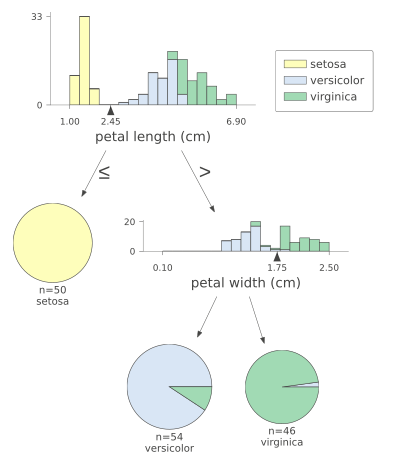

In [14]:
viz

### Show Prediction Path

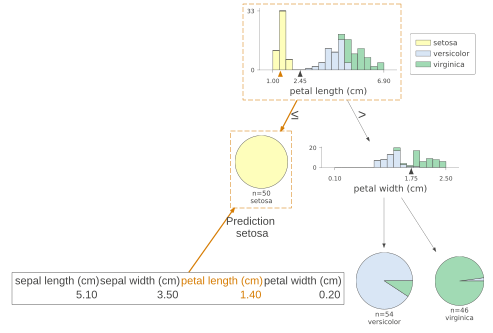

In [15]:
# Select a sample instance from the Iris dataset to show its prediction path
sample_instance = X_train[0]

viz_path = model_viz.view(x=sample_instance)
viz_path

## Show Node Number

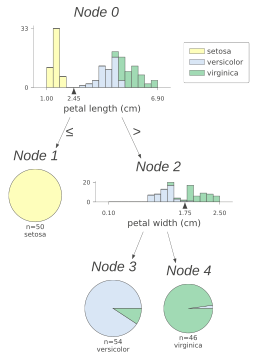

In [16]:
viz_nodes = model_viz.view(show_node_labels=True)
viz_nodes

## Show without graphs

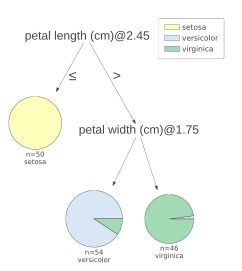

In [18]:
viz_no_graphs = model_viz.view(fancy=False)
viz_no_graphs

## Show just prediction path, NOTHING ELSE

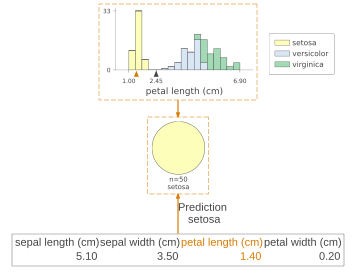

In [19]:
viz_just_path = model_viz.view(x=sample_instance, show_just_path=True)
viz_just_path

##Path Prediction in English

In [20]:
model_viz.explain_prediction_path(sample_instance)

'petal length (cm) < 2.45\n'

##feature Importtance

In [21]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': clas.feature_importances_
}).sort_values(by='importance', ascending=False)

display(feature_importance)

,feature,importance
2,petal length (cm),0.561991
3,petal width (cm),0.438009
1,sepal width (cm),0.000000
0,sepal length (cm),0.000000


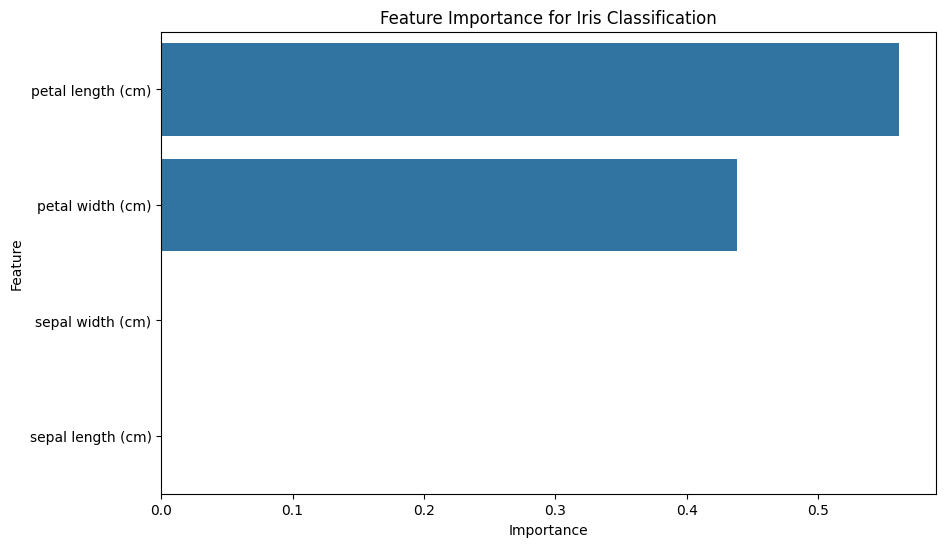

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance for Iris Classification')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Univariate Regression

In [35]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import dtreeviz

In [23]:
df_cars = pd.read_csv("cars.csv")

In [25]:
X,y = df_cars[['wt']],df_cars['mpg']

In [27]:
dt = DecisionTreeRegressor(max_depth = 3,criterion = "squared_error")
dt.fit(X,y)

DecisionTreeRegressor(max_depth=3)

In [28]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

In [29]:
ax = fig.gca()

In [30]:
rtreeviz_univar(dt,X,y,'wt','mpg',ax = ax)
plt.show()

/tmp/ipykernel_11442/3253243021.py:1: DeprecationWarning: rtreeviz_univar() function is deprecated starting from version 2.0. 
 For the same functionality, please use this code instead: 
 m = dtreeviz.model(...) 
 m.rtree_feature_space(...)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


/tmp/ipykernel_11442/41853097.py:2: DeprecationWarning: rtreeviz_univar() function is deprecated starting from version 2.0. 
 For the same functionality, please use this code instead: 
 m = dtreeviz.model(...) 
 m.rtree_feature_space(...)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


AttributeError: 'NoneType' object has no attribute 'rtree_feature_space'

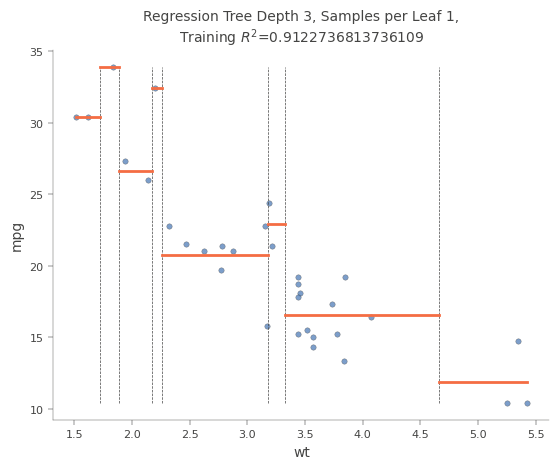

In [37]:
# Create a model_viz object for univariate regression
model_viz_univar = dtreeviz.rtreeviz_univar(
    dt, X, y,
    feature_names=['wt'],
    target_name='mpg'
)

# Generate and display the univariate regression visualization
regression_viz = model_viz_univar.rtree_feature_space(feature_name='wt', target_name='mpg')
regression_viz

## 3D regression


In [39]:
X3d, y3d = df_cars[['hp', 'disp']], df_cars['mpg']

dt3d = DecisionTreeRegressor(max_depth=3, criterion="squared_error")
dt3d.fit(X3d, y3d)

DecisionTreeRegressor(max_depth=3)

In [43]:
model_viz_3d = dtreeviz.model(
    dt3d, X3d, y3d,
    feature_names=['hp', 'disp'],
    target_name='mpg'
)

# Generate and display the 3D feature space visualization
viz_3d = model_viz_3d.rtree_feature_space3D(
    feature_name1='hp',
    feature_name2='disp'
)
viz_3d

TypeError: DTreeVizAPI.rtree_feature_space3D() got an unexpected keyword argument 'feature_name1'